# 🤖 K-Means Clustering

---

## 🎯 Objectives

After completing this, I will be able to:

- 📊 Use **scikit-learn’s K-Means** to cluster data  
- 🧠 Apply **K-Means clustering** on real-world data for **customer segmentation**  

---

## 📖 Introduction

**K-Means** is one of the most widely used algorithms for **clustering** in data science 🔍

It is especially useful when working with **unlabeled data**, helping uncover hidden patterns and group similar data points together.

---

## 🌍 Real-World Applications

K-Means is commonly used for:

- 👥 **Customer segmentation**  
- 🌐 Understanding **user behavior on websites**  
- 🔍 **Pattern recognition**  
- 🧩 **Feature engineering**  
- 📦 **Data compression**  

---

## 🛠️ Setup

Before starting, I need to ensure that all required libraries are installed 📦

---

## 💻 Next Step

Let’s install and import the necessary libraries 👇

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## 🧪 K-Means on a Synthetic Dataset

To better understand how K-Means works, I’ll start by creating a **synthetic dataset** 🎯

---

## 🎲 Set Random Seed

Before generating data, it’s important to set a **random seed** to ensure reproducibility 🔁

This means I’ll get the **same results every time** I run the code.

---

## 💻 Code

```python
import numpy as np

# Set random seed
np.random.seed(0)

In [ ]:
# Set random seed
np.random.seed(0)

## 🧪 Generate Synthetic Clusters with `make_blobs`

Now I will create **random clusters of data points** using the `make_blobs` function 🎯

---

## ⚙️ Input Parameters

I will configure the dataset with the following parameters:

- 🔢 **`n_samples = 5000`**  
  → Total number of data points  

- 📍 **`centers = [[4, 4], [-2, -1], [2, -3], [1, 1]]`**  
  → Defines the **cluster centers**  

- 📉 **`cluster_std = 0.9`**  
  → Controls how spread out each cluster is  

---

## 📤 Output

The function returns:

- 📊 **`X`** → Feature matrix of shape `[n_samples, n_features]`  
  - Contains the generated data points  

- 🏷️ **`y`** → Labels of shape `[n_samples]`  
  - Indicates the **cluster each point belongs to**  

---

In [9]:
X,y = make_blobs(n_samples=5000, centers=[[4, 4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)

Display the scatter plot of the randomly generated data.

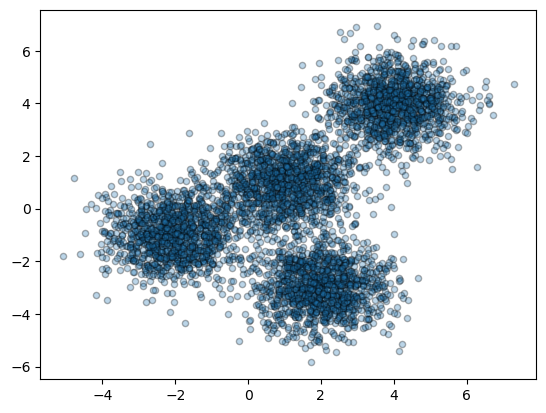

In [10]:
plt.scatter(X[:, 0], X[:, 1], marker='.', alpha=0.3, ec='k',s=80)

## ⚙️ Setting Up K-Means

Now that I have generated the random dataset, I can set up the **K-Means clustering model** 🤖

---

## 🔧 Parameters Used

The `KMeans` class has several parameters, but I will focus on these three:

- 🎯 **`init = "k-means++"`**  
  - Smart initialization method for centroids  
  - Helps speed up convergence and improves results  

- 🔢 **`n_clusters = 4`**  
  - Number of clusters to form  
  - Matches the number of centers used to generate the data  

- 🔁 **`n_init = 12`**  
  - Number of times the algorithm runs with different centroid seeds  
  - The best result (lowest inertia) is selected  

---

## 💻 Code

In [11]:
k_means = KMeans(init="k-means++", n_clusters=4, n_init=12)

Now let's fit the `KMeans` model with the feature matrix we created above, <b> X </b>.

In [12]:
k_means.fit(X)

KMeans(n_clusters=4, n_init=12)

Now let's get the label for each point in the model using the `k_means.labels_` attribute and save them as `k_means_labels`.

In [13]:
k_means_labels = k_means.labels_
k_means_labels

array([3, 2, 3, ..., 1, 3, 2], dtype=int32)

We will also get the coordinates of the cluster centers using `k_means.cluster_centers_` and save it as `k_means_cluster_centers`.

In [14]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[ 1.03586949,  0.98421298],
       [-2.04937124, -0.96701951],
       [ 4.00850926,  3.96921148],
       [ 1.98496071, -2.99565328]])

## 📊 Creating the Visual Plot

Now that I have:

- 📥 Generated the random dataset  
- 🤖 Initialized the K-Means model  

I can visualize the results to see how the data is clustered 👀

---

## 🎯 What I will do

- 📊 Plot the data points  
- 🎨 Color each point based on its assigned cluster  
- 📍 Display the cluster centroids  

---

## 🧠 Why this is useful

- 👀 Helps visually understand how K-Means groups data  
- 🎯 Shows how well the algorithm identified clusters  
- 📊 Makes it easy to compare predicted clusters with actual structure  

---

## 🚀 Next Step

Let’s plot the clustered data and visualize the results 👇

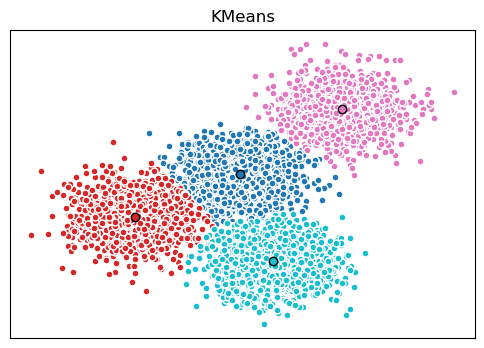

In [17]:
# Intialize the plot with the specified dimensions.
fig = plt.figure(figsize=(6, 4))

# Colors uses a color map, which will poroduce an array of colors based on
# the number of labels there are. We use set(k_means_labels) to get the
# unique labels.
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_labels))))
                      
# Create a plot
ax = fig.add_subplot(1, 1, 1)

# For loop that plots the date points and centroids.
# k will range from 0-3, which will match the possiblle clusters that each
# data point is in.
for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors):
    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means_labels == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means_cluster_centers[k]

    # Plot the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.', ms=10)

    # Plot the centroids with specified color, but wth a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

## 🧪 Exercise 1: Try a Different Number of Clusters

Now I will experiment with a different number of clusters to see how it affects the results 🔍

---

## 🎯 Task

Cluster the same dataset using:

- 🔢 **k = 3** (instead of 4)

---

## 🧠 What to Observe

After applying K-Means with `k = 3`, I should look for:

- 🎨 Changes in how data points are grouped  
- 📊 Whether some clusters are merged together  
- 📍 Differences in centroid positions  
- ⚠️ Loss of structure compared to the original (k = 4)  

---

## 💡 Insight

Since the original data was generated with **4 centers**, using `k = 3` will likely:

- 🔀 Merge two natural clusters into one  
- 📉 Reduce clustering accuracy  
- 🎯 Show how sensitive K-Means is to the choice of k  

---

## 💻 Next Step

Let’s run K-Means with `k = 3` and visualize the new clustering pattern 👇

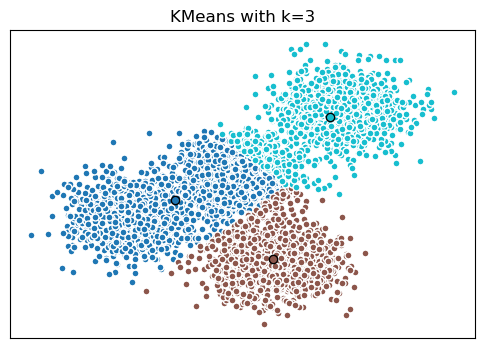

In [18]:
# Plot the clusters with k = 3
k_means_3 = KMeans(init="k-means++", n_clusters=3, n_init=12)
k_means_3.fit(X)
k_means_3_labels = k_means_3.labels_
k_means_3_cluster_centers = k_means_3.cluster_centers_
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_3_labels))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors):
    my_members = (k_means_3_labels == k)
    cluster_center = k_means_3_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.', ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)
ax.set_title('KMeans with k=3')
ax.set_xticks(())
ax.set_yticks(())
plt.show()  


## 🧪 Exercise 2: Try k = 5

Now I will experiment with a **larger number of clusters** 🔍

---

## 🎯 Task

Cluster the dataset using:

- 🔢 **k = 5**

---

## 🧠 What to Observe

After applying K-Means with `k = 5`, I should look for:

- 🎨 Whether existing clusters are **split into smaller groups**  
- 📍 New centroid positions  
- 📊 Changes in cluster boundaries  
- ⚠️ Possible over-segmentation of the data  

---

## 💡 Insight

Since the original dataset has **4 natural clusters**, using `k = 5` will likely:

- ✂️ Split one of the true clusters into two  
- 📈 Increase model complexity  
- 🎯 Show how K-Means behaves when **k is too large**  

---

## 💻 Next Step

Let’s run K-Means with `k = 5` and visualize the updated clustering 👇

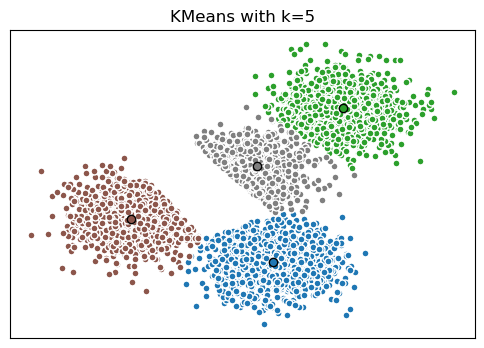

In [19]:
# Plot the clusters with k = 5
k_means_5 = KMeans(init="k-means++", n_clusters=5, n_init=12)
k_means_5.fit(X)
k_means_5_labels = k_means_5.labels_
k_means_5_cluster_centers = k_means_5.cluster_centers_
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_5_labels))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors):
    my_members = (k_means_5_labels == k)
    cluster_center = k_means_5_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.', ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)
ax.set_title('KMeans with k=5')
ax.set_xticks(())
ax.set_yticks(())
plt.show()

### 🧠 Understanding the Results

- 🔢 **k = 3**  
  - 📈 The **within-cluster sum of squares (WCSS)** is **higher** than for k = 4  
  - 🤝 Points from different natural clusters are grouped together  
  - ⚠️ This leads to **underfitting**  

---

- 🔢 **k = 5**  
  - 📉 The **WCSS** is **lower** than for k = 4  
  - ✂️ Natural clusters are split into smaller groups  
  - ⚠️ This leads to **overfitting**  

---

## 🎯 Key Takeaway

- 📊 **k = 4** is the optimal choice here because it matches the true structure of the data  
- ⚖️ Choosing k too small → underfitting  
- ⚖️ Choosing k too large → overfitting  

</details>

## 👥 Customer Segmentation with K-Means

---

## 📖 Introduction

Imagine I have a **customer dataset**, and I want to apply **customer segmentation** to better understand different types of customers 🎯

---

## 🧠 What is Customer Segmentation?

Customer segmentation is the process of:

- 👥 Dividing customers into groups  
- 🔍 Based on **similar characteristics or behaviors**  

---

## 💼 Why It Matters

Customer segmentation is a powerful business strategy because it allows companies to:

- 🎯 Target specific customer groups more effectively  
- 💰 Allocate marketing resources efficiently  
- 📈 Improve customer retention and engagement  

---

## 🌍 Real-World Example

For instance, one segment might include:

- 💎 High-profit customers  
- 🛡️ Low-risk individuals  
- 🛒 Customers likely to purchase or subscribe  

👉 The business goal would be to **retain and nurture these valuable customers**

---

## 🚀 Next Step

Now, I will apply **K-Means clustering** to segment customers based on their data 👇

### Load data from CSV file  
Let's use pandas to read the dataset from the cloud storage.

In [33]:
cust_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")

cust_df.head()


,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


## 🧹 Pre-processing

As I can see, the **`Address`** column in this dataset is a **categorical variable** 🏠

---

## ⚠️ Why This Matters

The **K-Means algorithm** relies on **Euclidean distance** 📏

- 🔢 Works well with **numerical data**  
- ❌ Not meaningful for **categorical variables**  

👉 Because distances between categories (like street names) don’t make sense mathematically

---

## 🧠 Possible Solution

One common approach would be:

- 🔄 Use **one-hot encoding** to convert categorical data into numerical format  

---

## 🎯 What I’ll Do Here

For simplicity and illustration purposes:

- 🚫 I will **exclude the `Address` feature**  
- 🤖 Run K-Means only on **numerical features**  

---

## 🚀 Next Step

Let’s prepare the dataset by removing categorical variables and selecting relevant features 👇

In [34]:
cust_df = cust_df.drop("Address", axis=1)

In [35]:
# Frop NaNs from the dataframe
cust_df = cust_df.dropna()
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


After dropping NaNs we still have 700 rows out of the original 849. Let's proceed with this smaller dataset.

## 📉 Normalizing over the standard deviation

Now let's normalize the dataset. But why do we need normalization in the first place?

Normalization is a statistical method that helps machine learning algorithms interpret features with different magnitudes and distributions equally. It transforms the features so they have a **mean of 0** and a **standard deviation of 1**.

We use `StandardScaler()` to normalize, or standardize, our dataset. ⚙️

In [44]:
X = cust_df.values[:, 1:] # leaves out 'CustomerID' column
Clus_dataSet = StandardScaler().fit_transform(X)

## 🧠 Modeling

I apply **K-Means clustering** with **k = 3** to group the data into clusters 🔍

### ✏️ Exercise 4

- 🎯 Perform K-Means clustering with **3 clusters**
- 🏷️ Extract the cluster labels from the fitted model
- 📊 Each data point is assigned to one of the 3 groups

👉 The result is a label for each observation indicating its cluster membership.

In [45]:
clusterNum = 3
k_means = KMeans(init="k-means++", n_clusters=clusterNum, n_init=12)
k_means.fit(X)
labels = k_means.labels_

## 🔎 Insights

We assign the **K-Means cluster labels** to each row in the dataframe 🧩

- 🏷️ Each observation is now linked to a specific cluster
- 📊 This allows us to analyze patterns within each group
- 🔍 We can better understand the structure hidden in the data

In [46]:
cust_df["Clus_km"] = labels

## 📍 Centroid Analysis

We can easily check the **centroid values** by averaging the features within each cluster 📊

- 📌 These values represent the **center of each cluster**
- 🧠 They summarize the typical profile of each group
- 🔍 They help us understand what defines each cluster from a domain perspective

In [ ]:
cust_df.groupby("Clus_km").mean()

## 📊 Customer Distribution

Let’s explore how customers are distributed based on **age, income, and education** 👥

- 📍 We use a **2D scatter plot**
- 📈 X-axis → Age
- 💰 Y-axis → Income
- 🎓 Marker size → Education level
- 🎨 Colors → Different class labels

👉 This visualization helps us understand how different customer segments are spread across key features.

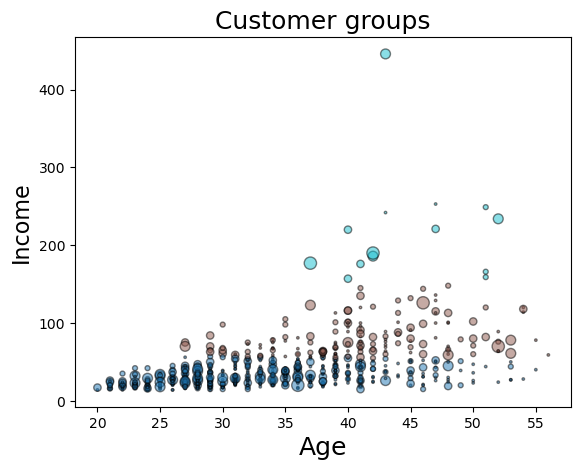

In [47]:
area = np.pi * (X[:, 1])**2  # circle area
plt.scatter(X[:, 0], X[:, 3], s=area, c=labels.astype(float), cmap='tab10', ec='k',alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)
plt.title('Customer groups', fontsize=18)
plt.show()

## 📊 Customer Distribution

We visualize customers using a **2D scatter plot** 👥

- 📍 X-axis → Age  
- 💰 Y-axis → Income  
- 🎓 Marker size → Education  
- 🎨 Color → Cluster labels  

👉 This helps us identify how different customer groups are distributed across key features.

In [53]:
# Create interactive 3D scatter plot
fig = px.scatter_3d(X, x=1, y=0, z=3, opacity=0.7, color=labels.astype(float))

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='Education'),
        yaxis=dict(title='Age'),
        zaxis=dict(title='Income')
    ))  # Remove color bar, resize plot

fig.show()

## 👥 Cluster Profiling

K-Means partitions customers into **mutually exclusive groups** (e.g., 3 clusters) 🔢  
Customers within each cluster share **similar demographic characteristics** 📊

---

### ✏️ Exercise 5

Create a **profile for each cluster** 🧠

- 👤 Identify common characteristics within each group
- 📊 Compare clusters based on age, income, and education
- 🔍 Describe what makes each cluster unique
- 💡 Summarize each group into a clear customer persona

👉 The goal is to turn raw clusters into **meaningful customer segments**

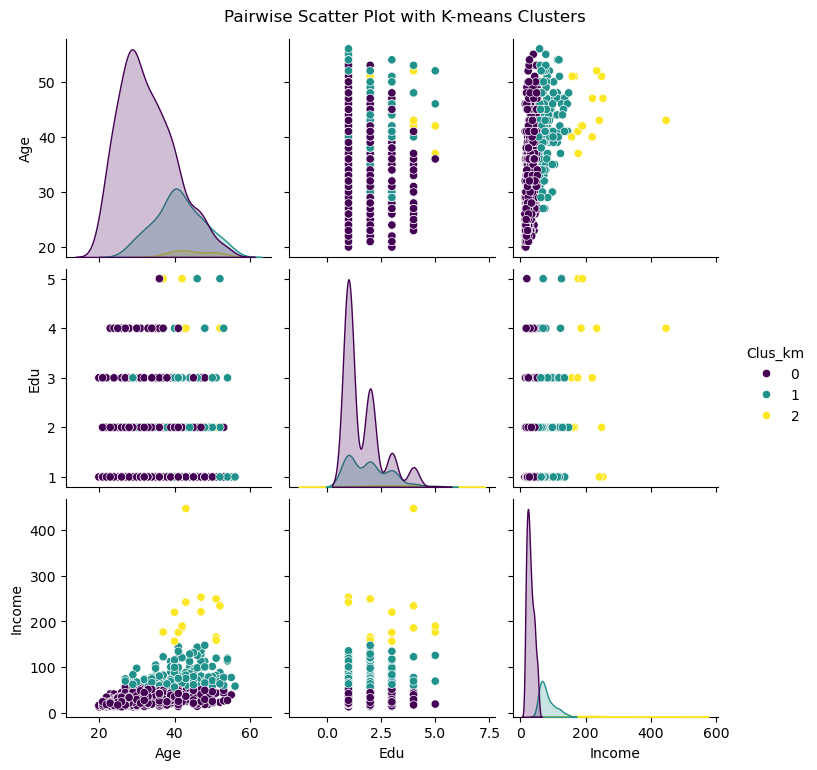

In [52]:
cust_df_sub = cust_df[['Age', 'Edu','Income','Clus_km']].copy() 
sns.pairplot(cust_df_sub, hue='Clus_km', palette='viridis', diag_kind='kde') 
plt.suptitle('Pairwise Scatter Plot with K-means Clusters', y=1.02)
plt.show()

## 👥 Cluster Profiles

Based on the observations, we can define the following customer segments 🧠📊

- 👴💼 **Late Career, Affluent, and Educated**  
  → High income, higher education level, experienced professionals  

- 👨‍💻📊 **Mid Career and Middle Income**  
  → Stable income, working professionals in the middle of their careers  

- 🎓💰 **Early Career and Low Income**  
  → Younger customers, just starting their careers with lower income  

👉 These profiles help transform clusters into clear, actionable customer segments 🎯